In [142]:
from dotenv import load_dotenv
load_dotenv()

True

In [143]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(model="llama-3.1-8b-instant", model_provider="groq")
# llm = init_chat_model(model="gemma-3-27b-it", model_provider="google_genai")

In [144]:
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

    summary: str

    category: str
    priority: str
    issue_analyzer_confidence: float
    sentiment: float

In [145]:
from pydantic import BaseModel, Field, model_validator
from langchain_core.output_parsers import PydanticOutputParser

class IssueExtractionResult(BaseModel):
    category: str = Field(
        description="Categorize the issue: Billing, Technical, Login, or General.",
        default="General"
    )
    priority: str = Field(
        description="Assess priority: Low, Medium, High, or Urgent.",
        default="Low"
    )
    confidence: float = Field(
        description="A score from 0.0 to 1.0 indicating how confident you are in this classification. A vague message should have a low score.", 
        ge=0.0, 
        le=1.0,
        default=0.0
    )
    sentiment_score: float = Field(
        description="A score from -1.0 (extremely negative/angry) to 1.0 (extremely positive/happy). 0.0 is neutral.",
        default=0.0
    )

    # The Dynamic Validator
    @model_validator(mode='before')
    @classmethod
    def drop_empty_strings(cls, data: any) -> any:
        """
        Scans the incoming JSON dictionary. If any string is empty or just spaces,
        it removes the key entirely, forcing Pydantic to use the field's default value.
        """
        # Ensure the incoming data is actually a dictionary
        if isinstance(data, dict):
            cleaned_data = {}
            for key, value in data.items():
                # If it's a string and it's empty/blank, we skip adding it to our clean dict
                if isinstance(value, str) and not value.strip():
                    continue 
                # Otherwise, keep the data
                cleaned_data[key] = value
            return cleaned_data
        return data

issue_extraction_parser = PydanticOutputParser(pydantic_object=IssueExtractionResult)
print(issue_extraction_parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"category": {"default": "General", "description": "Categorize the issue: Billing, Technical, Login, or General.", "title": "Category", "type": "string"}, "priority": {"default": "Low", "description": "Assess priority: Low, Medium, High, or Urgent.", "title": "Priority", "type": "string"}, "confidence": {"default": 0.0, "description": "A score from 0.0 to 1.0 indicating how confident you are in this classification. A vague message should have a low score.", "maximum": 1.0, "minimum": 0.0, "title": "Confidence", "type": "number"}

In [146]:
from langchain_core.messages import HumanMessage

def generate_transcript(messages: list[BaseMessage]) -> str:
    transcript = ""
    for msg in messages:
        role = "User" if isinstance(msg, HumanMessage) else "Bot"
        transcript += f"{role}: {msg.content}\n"
    return transcript

In [147]:
from langchain_core.prompts import PromptTemplate

def analyze_issue(state: AgentState):
    prompt = PromptTemplate(
        template="""
            You are a strict data extraction algorithm."
            Analyze the messages and extract the exact fields requested.
                  
            {format_instructions}

            PAST CONTEXT SUMMARY:
            {summary}

            RECENT TRANSCRIPT:
            {transcript}
        """,
        input_variables=["summary", "transcript"],
        partial_variables={"format_instructions": issue_extraction_parser.get_format_instructions()}
    )

    analyzer_chain = prompt | llm | issue_extraction_parser

    try:
        summary = state.get('summary', 'No prior context.')
        transcript = generate_transcript(state["messages"])
        result = analyzer_chain.invoke({"summary": summary, "transcript": transcript})
        print(f"[analyze_issue] {result}")
        print(f"[analyze_issue] {type(result)}")
    except Exception as e:
        print(f"[analyze_issue] [ERROR] {e}")
        result = IssueExtractionResult()
    
    return {
        "category": result.category,
        "priority": result.priority,
        "issue_analyzer_confidence": result.confidence,
        "sentiment": result.sentiment_score
    }


In [148]:
from typing import Literal

def get_sentiment(sentiment_score: float) -> Literal["Angry", "Frustrated", "Neutral", "Satisfied", "Happy"]:
    score = max(-1.0, min(1.0, sentiment_score))
    
    if score <= -0.6:
        return "Angry"
    elif score <= -0.2:
        return "Frustrated"
    elif score < 0.2:
        return "Neutral"
    elif score < 0.6:
        return "Satisfied"
    else:
        return "Happy"

In [149]:
from langchain_core.messages import SystemMessage

def generate_reply(state: AgentState):
   default_issue_analize_result = IssueExtractionResult()
   category = state.get("category", default_issue_analize_result.category)
   priority = state.get("priority", default_issue_analize_result.priority)
   sentiment_score = state.get("sentiment_score", default_issue_analize_result.sentiment_score)
   sentiment = get_sentiment(sentiment_score)
   summary = state.get('summary', 'No prior context.')

   sys_prompt = f"""You are a world-class, empathetic customer support agent.
   
   PAST CONTEXT SUMMARY:
   {summary}

   CURRENT TICKET CONTEXT:
   - Issue Category: {category}
   - Priority Level: {priority}
   - User's Current Emotion: {sentiment}
    
   YOUR INSTRUCTIONS:
   1. Acknowledge their issue directly based on the '{category}'.
   2. Adjust your tone perfectly to match their '{sentiment}' emotion. 
      - If they are 'Angry' or 'Frustrated', be deeply apologetic, highly professional, and concise. Get straight to the point.
      - If they are 'Neutral' 'Satisfied' or 'Happy', be warm, conversational, and friendly.
   3. IMPORTANT: Do NOT explicitly mention the category, priority or emotion. Just naturally embody the correct tone.
   """

   messages = [SystemMessage(content=sys_prompt)] + state["messages"]

   response = llm.invoke(messages)
   return {"messages": [response]}

In [ ]:
from langchain_core.messages import HumanMessage, RemoveMessage

def summarize_conversation(state: AgentState):
    prompt = PromptTemplate(
        template="""Update the following conversation summary based on the new messages.

        CURRENT SUMMARY: {summary}

        NEW MESSAGES TO SUMMARIZE:
        {transcript}
        """,
        input_variables=["summary", "messages"]
    )

    # summarize everything except the last two
    summary = state.get("summary", "")
    messages = state["messages"]
    messages_to_summarize = messages[:-2]
    transcript = generate_transcript(messages_to_summarize)
    
    summarizer_chain = prompt | llm
    new_summary = summarizer_chain.invoke({
        "summary": summary,
        "transcript": transcript
    })

    deleted_messages = [RemoveMessage(id=msg.id) for msg in messages_to_summarize]

    return {
        "summary": new_summary.content,
        "messages": deleted_messages,
    }


In [151]:
from langgraph.graph import END

def should_summarize(state: AgentState):
    messages = state["messages"]

    # summarize only if messages are more than 6
    if len(messages) > 6:
        return "summarize_conversation"
    
    return END

In [ ]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

workflow.add_node("analyze_issue", analyze_issue)
workflow.add_node("generate_reply", generate_reply)
workflow.add_node("summarize_conversation", summarize_conversation)

workflow.add_edge(START, "analyze_issue")
workflow.add_edge("analyze_issue", "generate_reply")
workflow.add_conditional_edges(
    "generate_reply", 
    should_summarize,
    {
        "summarize_conversation": "summarize_conversation",
        END: END,
    }
)
workflow.add_edge("summarize_conversation", END)

graph = workflow.compile()

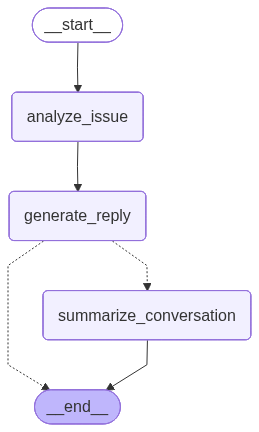

In [153]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [155]:
from langchain_core.messages import HumanMessage
from pprint import pprint

result = graph.invoke({"messages": [HumanMessage(content="Hello")]})
pprint(result)

[analyze_issue] category='General' priority='Low' confidence=0.0 sentiment_score=0.0
[analyze_issue] <class '__main__.IssueExtractionResult'>
{'category': 'General',
 'issue_analyzer_confidence': 0.0,
 'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='9d839f97-1200-4046-91d3-bc0d3f0657f9'),
              AIMessage(content="Hello! How can I assist you today? Is there something on your mind that you'd like to discuss or a question you're looking to get answered? I'm all ears.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 209, 'total_tokens': 246, 'completion_time': 0.079920149, 'completion_tokens_details': None, 'prompt_time': 0.022624368, 'prompt_tokens_details': None, 'queue_time': 0.046631822, 'total_time': 0.102544517}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq